# Decision Tree Regression

Decision Tree Regression is a supervised machine learning algorithm
used to predict continuous numerical values.

A decision tree makes predictions by repeatedly splitting the data
into smaller groups based on feature values.

The tree consists of:

- Root Node
- Decision Nodes
- Branches
- Leaf Nodes

For regression, the prediction at a leaf is usually based on the
average target value of the training samples that reach that leaf.

Basic idea:

Data
 ↓
Feature-based Split
 ↓
More Splits
 ↓
Leaf Node
 ↓
Average Target Value
 ↓
Prediction

## How Decision Tree Regression Works

Suppose we want to predict restaurant tip.

The tree might learn rules such as:

Is total_bill <= 20?
        |
       Yes
        ↓
Predict a smaller tip

        No
        ↓
Is total_bill <= 40?
        |
       Yes
        ↓
Predict a medium tip

        No
        ↓
Predict a larger tip

The model automatically learns the splitting rules from the training
data.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

Therefore:

total_bill + size
        ↓
Decision Tree Regressor
        ↓
tip

In [6]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 2)
Testing: (49, 2)


## Creating the Decision Tree

We will use:

DecisionTreeRegressor

Unlike KNN, Decision Trees do not require feature scaling.

The tree learns splitting rules directly from the feature values.

In [8]:
model = DecisionTreeRegressor(
    random_state=42
)

In [9]:
model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [10]:
y_pred = model.predict(
    X_test
)

y_pred[:10]

array([4.19, 1.92, 3.61, 4.34, 2.  , 3.58, 2.05, 1.5 , 2.2 , 1.64])

In [11]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,4.19
1,2.00,1.92
2,2.00,3.61
3,5.16,4.34
4,2.00,2.00
5,2.00,3.58
6,2.56,2.05
7,2.52,1.50
8,3.23,2.20
9,3.00,1.64


## Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and
predicted values.

Lower MAE indicates better performance.

In [12]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.8177551020408164


In [13]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 1.0047040816326531


In [14]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1.0023492812551187


In [15]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.1962183089778119


## Important Decision Tree Hyperparameters

Important parameters include:

### max_depth

Controls the maximum depth of the tree.

Small value:
→ Simpler tree
→ Can cause underfitting

Large value:
→ More complex tree
→ Can cause overfitting


### min_samples_split

Minimum number of samples required to split an internal node.


### min_samples_leaf

Minimum number of samples that must be present in a leaf node.


### max_features

Controls the number of features considered when looking for the best
split.

In [16]:
model_depth = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

model_depth.fit(
    X_train,
    y_train
)

depth_pred = model_depth.predict(
    X_test
)

print(
    "R²:",
    r2_score(y_test, depth_pred)
)

R²: 0.36004989451489156


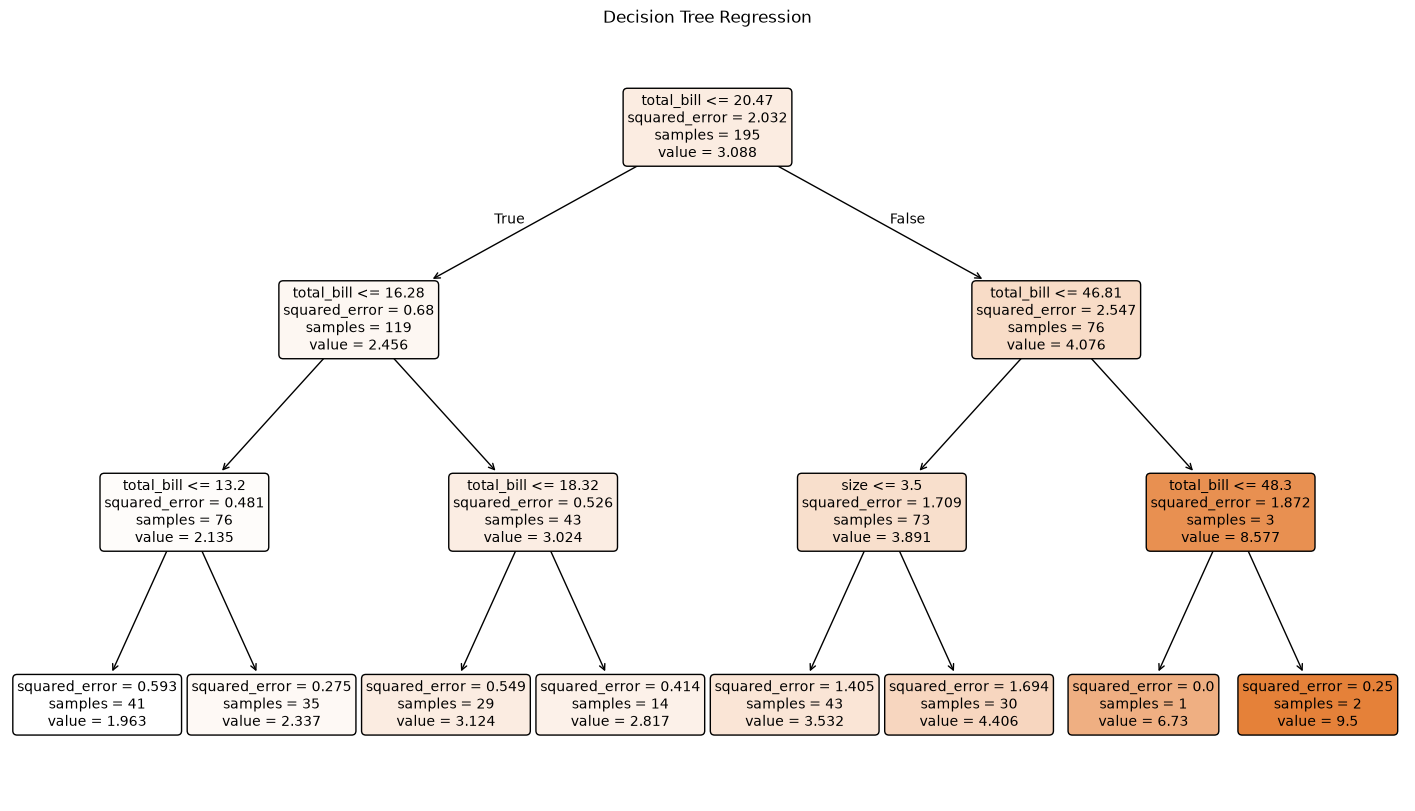

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model_depth,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Regression")

plt.show()

## Decision Tree Overfitting

Decision Trees can easily overfit because they can keep splitting the
data until individual observations are isolated.

Very deep tree:

Training Error → Very Low
Testing Error  → Potentially High

This means the model has learned the training data too closely.

We can control overfitting using:

- max_depth
- min_samples_split
- min_samples_leaf
- max_features

In [18]:
depths = range(1, 16)

results = []

for depth in depths:

    tree = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    tree.fit(
        X_train,
        y_train
    )

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    results.append({
        "Depth": depth,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Test_RMSE": test_rmse
    })

results_df = pd.DataFrame(results)

results_df

,Depth,Train_R2,Test_R2,Test_RMSE
0,1,0.307169,0.258824,0.962522
1,2,0.521607,0.162714,1.023027
2,3,0.577510,0.360050,0.894382
3,4,0.609325,0.333339,0.912857
4,5,0.664244,0.332222,0.913621
5,6,0.745077,0.284074,0.945984
6,7,0.808868,0.267148,0.957102
7,8,0.874072,0.140270,1.036647
8,9,0.907921,0.186053,1.008667
9,10,0.936363,0.186158,1.008602


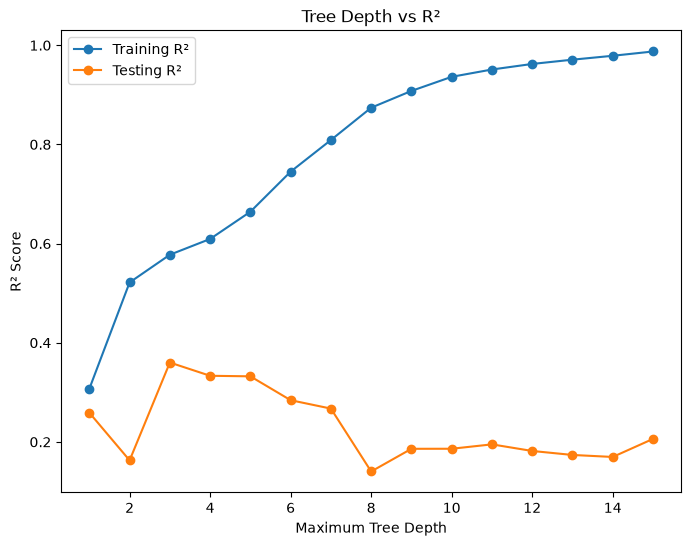

In [19]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["Depth"],
    results_df["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    results_df["Depth"],
    results_df["Test_R2"],
    marker="o",
    label="Testing R²"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("R² Score")
plt.title("Tree Depth vs R²")

plt.legend()

plt.show()

In [20]:
best_depth = results_df.loc[
    results_df["Test_RMSE"].idxmin(),
    "Depth"
]

print("Best Depth:", best_depth)

Best Depth: 3


In [21]:
final_model = DecisionTreeRegressor(
    max_depth=int(best_depth),
    random_state=42
)

final_model.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [22]:
final_pred = final_model.predict(
    X_test
)

final_mae = mean_absolute_error(
    y_test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred
    )
)

final_r2 = r2_score(
    y_test,
    final_pred
)

print("Best Depth:", best_depth)
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Best Depth: 3
MAE : 0.7146073910386421
RMSE: 0.8943820739821954
R²  : 0.36004989451489156


## Feature Importance

Decision Trees can calculate feature importance.

Feature importance indicates how useful each feature was when making
splits in the tree.

A higher value means the feature contributed more to the tree's
splitting decisions.

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,total_bill,0.94097
1,size,0.05903


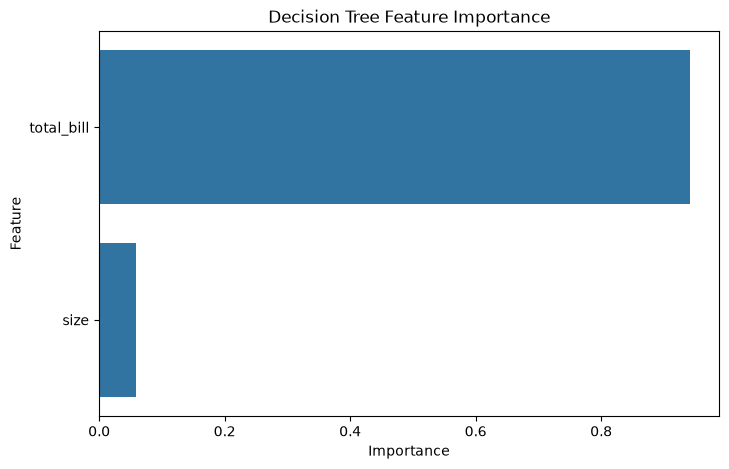

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")

plt.show()

In [25]:
new_data = pd.DataFrame({
    "total_bill": [50],
    "size": [3]
})

prediction = final_model.predict(
    new_data
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 9.5


## Advantages of Decision Tree Regression

- Easy to understand.
- Easy to visualize.
- Does not require feature scaling.
- Can model non-linear relationships.
- Can capture feature interactions.
- Can work with different types of features after appropriate
  preprocessing.

## Disadvantages of Decision Tree Regression

- Can easily overfit.
- Small changes in data can produce a different tree.
- Deep trees can become very complex.
- A single tree may have weaker generalization than ensemble methods.